This notebook is produce inline with the course produced by Prof. Zhengtao Gan (The University of Texas at El Paso), from which the format and conventions are adopted. For his course please follow https://drzgan.github.io/Python_CFD/0.intro_CFD.html. 

# Computational Fluid Dynamics (CFD)

CFD is a field of study that focuses on using numerical methods to analyse and solve governing equations in fluid dynamics that, at the highest level, have particularly complicated or non-existent analytical solutions. Fluid dynamics (FD) are ultimately governed by the Navier-Stokes Equations (NS Eq<sup>n</sup>):

- Momentum equation $\frac{\partial \vec{u}}{\partial t} + (\vec{u} \cdot \nabla) \vec{u}  = -\frac{1}{\rho} \nabla p + \nu \nabla ^2 \vec{u} + f$
- Continuity equation $\nabla \cdot \vec{u} = 0$

where $\vec{u}$ os the velocity field, $\rho$ is the fluid density, $p$ the pressure field, $\nu$ is the kinematic velocity, $f$ represents some body force (e.g. gravity) and all other symbols represent their usual notation.

The computational techniques developed in this notebook aim to transform PDEs into linear algebraic eq<sup>ns</sup>. Techniques include the *Finite Element Method*, *Finite Difference Method*, and *Finite Volume Method*, with which approximate models can be readily produced.

## 1<sup>D</sup> Linear Convection

The 1<sup>D</sup> Linear Convection Eq<sup>n</sup> or 1st-Order Wave Eq<sup>n</sup> is one of the simplest FD model:

$$\frac{\partial u}{\partial t} \pm c\frac{\partial u}{\partial x} = 0$$

This eq<sup>n</sup> represents the propagation of a wave with speed $c$ either 'left' or 'right' ($\pm$ respectively) that does not change shape. We fix the initial condition $u(x, 0) = u_0(x)$. By direct substitution we can show that $u(x, t) = u_0 (x \mp ct)$. Let $\eta = x \mp ct$. Using the chain rule:

$$\frac{\partial u_0}{\partial t} = \frac{d u_0}{d \eta} \frac{\partial \eta}{\partial t} \equiv \mp c \frac{d u_0}{d \eta}$$

and

$$\frac{\partial u_0}{\partial x} = \frac{d u_0}{d \eta} \frac{\partial \eta}{\partial x}  \equiv \frac{d u_0}{d \eta}$$

therefore

$$LHS = \mp c \frac{d u_0}{d \eta} \pm c \frac{d u_0}{d \eta} = 0 = RHS$$

For now let $c$ absorb the sign. To solve this equation numerically we discretise in space and time using Forward/ Backward Difference scheme for the time/ space derivative respectively. Space is unitised into points indexed from $i = 0, 1, ..., N$ and time intervals are taken in steps of $\Delta t$. Using the definition of the derivative:

$$\frac{\partial u}{\partial x} \approx \frac{u(x + \Delta x) - u(x)}{\Delta x} \lim_{\Delta x \rightarrow 0}(\approx \rightarrow =)$$
$$\implies \frac{u_i^{n+1} - u_i^n}{\Delta t} + c \frac{u_i^{n} - u_{i-1}^n}{\Delta x} = 0$$

Where $n$ and $n+1$ are consecutive time steps and $i$ and $i-1$ are neighbouring points in space. With known initial conditions it therefore follows that:


$$u_i^{n+1} = u_i^n - c \frac{\Delta t}{\Delta x}(u_i^{n} - u_{i-1}^n)$$

Let's analyse this in python, starting by initialising our libraries.

In [298]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, sys

# Plots appear in notebook rather than seperate view
%matplotlib inline

We define an evenly spaced grid of points, e.g. $x \in [0,1]$. Let `n_grid` be the number of grid point and `delta_x` or `d_x` be a constant spacing between any pair of adjacent points.

The initial velocity $u_0$ can be configured in the function below, so long as it always produces a numpy array. For this investigation we will use a top hat function:

$$ u = \begin{cases} 1 & 0.1 < x < 0.2 \\ 0 & \text{elsewhere} \end{cases}

In [299]:
def top_hat(n_grid: int, domain: list[float] = [0.0, 1.0], centre: float = 0.25, width: float = 0.1, max: float = 1.0, min: float = 0.0) -> np.ndarray:
    x = np.linspace(domain[0], domain[1], n_grid)
    array = np.full(n_grid, min, dtype=float)
    mask = (x >= centre - width / 2) & (x <= centre + width / 2)
    array[mask] = max
    return array

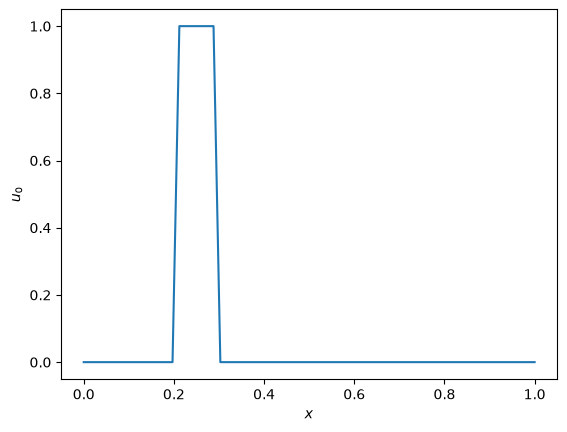

In [300]:
n_grid, x_range = 67, [0.0, 1.0]

u_0 = top_hat(n_grid=n_grid, domain=x_range)
x = np.linspace(0.0, 1.0, n_grid)
plt.plot(x, u_0)
plt.xlabel(r"$x$")
plt.ylabel(r"$u_0$")
plt.show()

We simulateneously define the number of timesteps, `n_tsteps`, `delta_t`, and `c`. `matplotlib.pyplot` still defines the plotting environment and can be used to plot at the expense of a simple configurations. 

Let's explore how this state evolves over time under the discretised convection eq<sup>n</sup>, performing our numeric approximation outlined previously. We first initialise the evolution array (preventing excessive storage allocation) and then populate it with sucessive speed timesteps. For a given $n$ in time, the function numerically finds the next spatial state from the previous one; implemented by nesting the spatial loop in the temporal loop.

In [ ]:
def linear_convection(u_0: np.ndarray, domain: list[float], n_x: int, n_t: int, d_t: float, c: float = 1.0) -> np.ndarray:
    d_x = abs(domain[1] - domain[0]) / (n_x - 1) # Last point must exist at ends of grid so spacing requires 1 less free point.
    
    u = np.zeros([n_t+1, n_x]) # add timestep for initial condition
    u[0] = u_0

    for n in range(n_t):
        for i in range(1, n_x): # start at 1 so that i-1 doesn't produce -1 (use end of array)
            u[n+1, i] = u[n, i] - c * d_t/d_x * (u[n, i] - u[n, i-1])

    return u

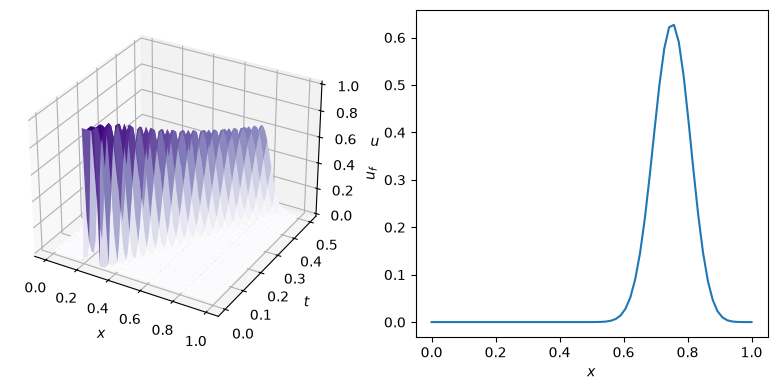

In [302]:
n_grid, x_range = 67, [0.0, 1.0]
n_timesteps, delta_t = 50, 0.01

u_0 = top_hat(n_grid=n_grid, domain=x_range)
u = linear_convection(u_0=u_0, domain=x_range, n_x=n_grid, n_t=n_timesteps, d_t=delta_t)
x = np.linspace(x_range[0], x_range[1], n_grid)
t = np.linspace(0, n_timesteps * delta_t, u.shape[0])

X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, T, u, cmap="Purples")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")
ax1.set_zlabel(r"$u$")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, u[-1])
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

As we can see the hat is successfully progressing over time at a constant speed. The final state on the right has moved, but the hat has smoothed over time. Furthermore, while testing it was reveled that unstable artefacts may appear for runs with reversed speed or lower temporal resolution.

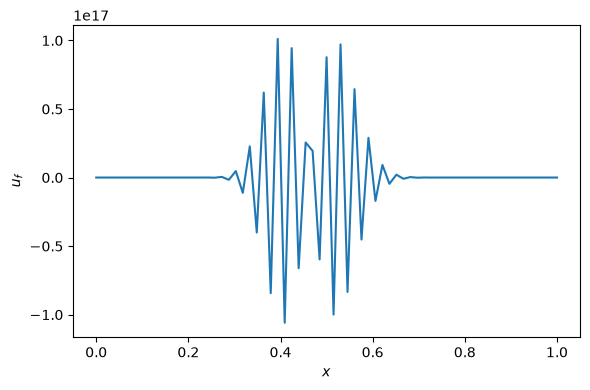

In [303]:
n_grid, x_range = 67, [0.0, 1.0]
n_timesteps, delta_t = 50, 0.01

u_0 = top_hat(n_grid=n_grid, domain=x_range)
u = linear_convection(u_0=u_0, domain=x_range, n_x=n_grid, n_t=n_timesteps, d_t=delta_t, c=-1.0)
x = np.linspace(x_range[0], x_range[1], n_grid)

X, T = np.meshgrid(np.linspace(x_range[0], x_range[1], n_grid), np.linspace(0, n_timesteps*delta_t, n_timesteps))

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()
ax.plot(x, u[-1])
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

A big part of this error will be the accuracy of our finite difference schemes. Our two differencing schemes have error $\mathcal{O}(\Delta x)$ which when combined produce a central differencing scheme with error $\mathcal{O}(\Delta x^2)$

## Nonlinear Convection

Suppose instead we had a feedback loop for the speed of the wave, i.e. it's speed was coupled to its motion somehow. Dimensionally we can assert that the 1<sup>D</sup> Linear Convection Eq<sup>n</sup> is

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = 0$$

absorbing the sign for now. This is now a nonlinear eq<sup>n</sup>. Using the same discretisation we now have a nonlinear numerical solution:

$$u_i^{n+1} = u_i^n - u_i^n \frac{\Delta t}{\Delta x}(u_i^{n} - u_{i-1}^n)$$

Let's see how this evolves over time with a more granular resolution.

In [ ]:
def nonlinear_convection(u_0: np.ndarray, domain: list[float], n_x: int, n_t: int, d_t: float) -> np.ndarray:
    d_x = abs(domain[1] - domain[0]) / (n_x - 1)

    u = np.zeros([n_t+1, n_x])
    u[0] = u_0

    for n in range(n_t):
        for i in range(1, n_x):
            u[n+1, i] = u[n, i] * (1 - d_t/d_x * (u[n, i] - u[n, i-1]))

    return u

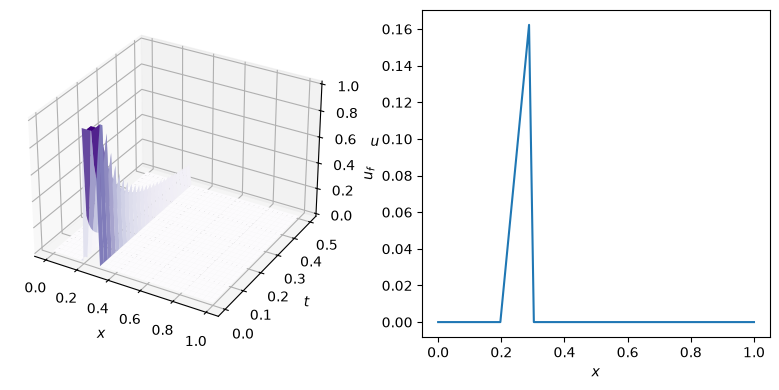

In [305]:
n_grid, x_range = 67, [0.0, 1.0]
n_timesteps, delta_t = 50, 0.01

u_0 = top_hat(n_grid=n_grid, domain=x_range)
u = nonlinear_convection(u_0=u_0, domain=x_range, n_x=n_grid, n_t=n_timesteps, d_t=delta_t)
x = np.linspace(x_range[0], x_range[1], n_grid)
t = np.linspace(0, n_timesteps * delta_t, u.shape[0])

X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, T, u, cmap="Purples")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")
ax1.set_zlabel(r"$u$")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, u[-1])
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

To stress-test the approximation, let's also observe if the initial conditions (speeds) where switched to negative values. While we don't know yet if the shape is correct, we are anticipate the same shape but inveretd.

C:\Users\Samue\AppData\Local\Temp\ipykernel_4776\4134683195.py:9: RuntimeWarning: overflow encountered in scalar multiply
  u[n+1, i] = u[n, i] * (1 - d_t/d_x * (u[n, i] - u[n, i-1]))
C:\Users\Samue\AppData\Local\Temp\ipykernel_4776\4134683195.py:9: RuntimeWarning: invalid value encountered in scalar subtract
  u[n+1, i] = u[n, i] * (1 - d_t/d_x * (u[n, i] - u[n, i-1]))
C:\Users\Samue\AppData\Local\Temp\ipykernel_4776\4134683195.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  u[n+1, i] = u[n, i] * (1 - d_t/d_x * (u[n, i] - u[n, i-1]))


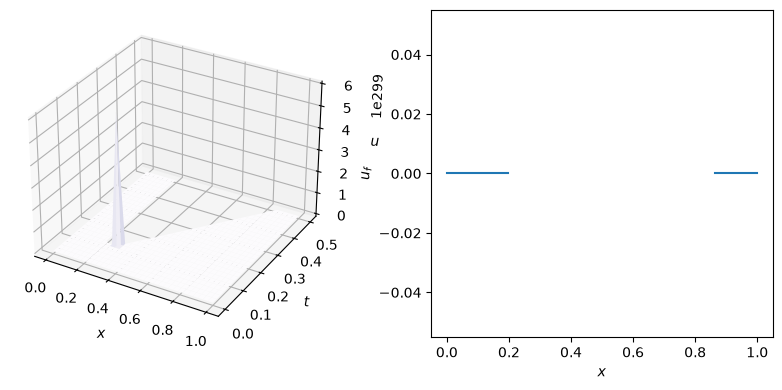

In [306]:
n_grid, x_range = 67, [0.0, 1.0]
n_timesteps, delta_t = 50, 0.01

u_0 = top_hat(n_grid=n_grid, domain=x_range)
u = nonlinear_convection(u_0=-u_0, domain=x_range, n_x=n_grid, n_t=n_timesteps, d_t=delta_t)
x = np.linspace(x_range[0], x_range[1], n_grid)
t = np.linspace(0, n_timesteps * delta_t, u.shape[0])
X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, T, u, cmap="Purples")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")
ax1.set_zlabel(r"$u$")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, u[-1])
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

The method has clearly failed for negative values. This is due to limitations in the backward scheme, $\frac{u_i^n - u_{i-1}^n}{\Delta x}$, which is much less effective when dealing with nonlinear convection coefficients. To address this issue, we introduce an upwind scheme to handle both positive and negative convection coefficients.

In [ ]:
def upwind_scheme(c: float):
    return max(c/(abs(c)+1e-6), 0), max(-c/(abs(c)+1e-6), 0)

def upwind_nonlinear_convection(u_0: np.ndarray = u_0, domain: list = x_range, n_t: int = n_timesteps, n_x: int = n_grid, d_t: float = delta_t) -> np.ndarray:
    d_x = abs(domain[1] - domain[0]) / (n_x - 1)

    u = np.zeros([n_t+1, n_x])
    u[0] = u_0

    for n in range(n_t):
        for i in range(1, n_x-1): # ignore last iteration as differential value depends on (i+1)th value
            
            # Coefficients to west & east side of the node (i-1) or (i+1) respectively
            fe1, fe2 = upwind_scheme(u[n, i])
            fw1, fw2 = upwind_scheme(u[n, i])

            # Differential values on west & east side interface
            ue = u[n, i] * fe1 + u[n, i+1] * fe2
            uw = u[n, i-1] * fw1 + u[n, i] * fw2

            u[n+1, i] = u[n, i] * (1 - d_t/d_x * (ue - uw))

    return u

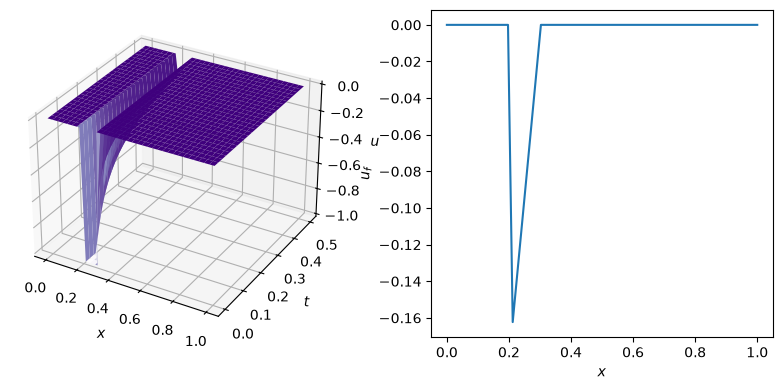

In [308]:
n_grid, x_range = 67, [0.0, 1.0]
n_timesteps, delta_t = 50, 0.01

u_0 = top_hat(n_grid=n_grid, domain=x_range)
u = upwind_nonlinear_convection(-u_0)
x = np.linspace(x_range[0], x_range[1], n_grid)
t = np.linspace(0, n_timesteps * delta_t, u.shape[0])

X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, T, u, cmap="Purples")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$t$")
ax1.set_zlabel(r"$u$")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, u[-1])
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u_f$")

plt.tight_layout()
plt.show()

This has now produced the same shape as the positive initial condition and stabalised the handling of negative values.

# Convergence & the CFL Condition

Going back to the linear convections, this section aims to resolve why do the numercial solutions diffuse over time, and the divergence at negative $c$. So far we've been using the fixed spatial grid and timestep parameters but how does the outcome vary with grid size and timestep?

At this point we also define the CFL, or *Courant*, number, $\sigma$, where

$$\sigma = \frac{u \Delta t}{\Delta x} \leq \sigma_{max}$$

where $u$ is the wavespeed and $\sigma_{max}$ is the maximum value for which the discretisation is stable. Let's see what this means by varying n_x in a fixed range $x \in [0,1]$:

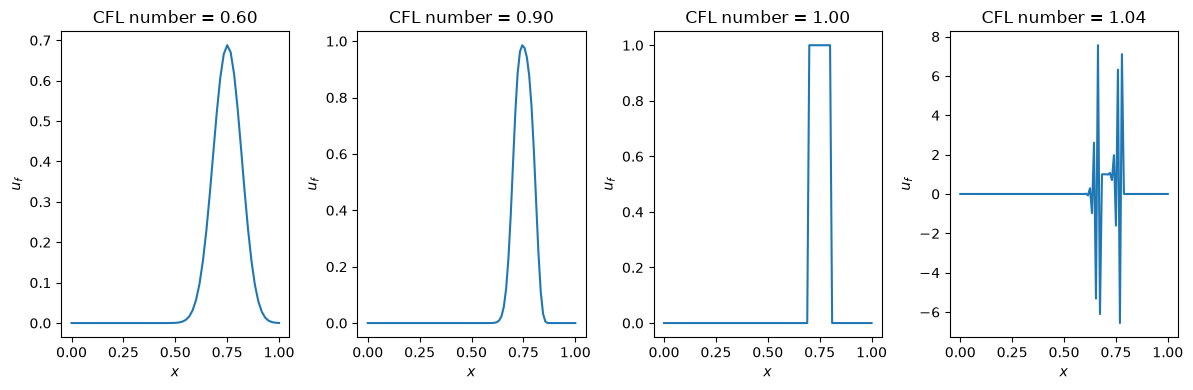

In [309]:
n_grids, x_range = [61, 91, 101, 105], [0.0, 1.0]
n_timesteps, delta_t = 50, 0.01
c = 1.0

fig = plt.figure(figsize=(12, 4))

for n_grid in n_grids:
    delta_x = (x_range[1] - x_range[0]) / (n_grid - 1)
    
    u_0 = top_hat(domain=x_range, n_grid=n_grid)
    u = linear_convection(u_0=u_0, domain=x_range, n_x=n_grid, n_t=n_timesteps, d_t=delta_t)
    x = np.linspace(x_range[0], x_range[1], n_grid)

    ax = fig.add_subplot(1, len(n_grids), n_grids.index(n_grid)+1)
    ax.plot(x, u[-1], label=f"$n_x={n_grid}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$u_f$")
    ax.set_title(f"CFL number = {c * delta_t / delta_x:.2f}")

plt.tight_layout()
plt.show()

As the grid resolution is increased, the accuracy of its shape increases as we numerically identify its spatial components as it propagates through discrete time. The more resolute the grid, the more the wave retains its shape. However, as the spatial resolution has been increased passed some CFL threshold the shape breaks down. This occurs because over the period $\Delta t$ the wave traverses a distance greater than the grid spacing, $\Delta x$, due to its motion as a results of its speed. Let's rebuild our linear_convection fucntion using the CFL number to calculate the optimal timestep (rearranging the CFL eq<sup>n</sup>) depending on our choice of $\Delta x$.

In [ ]:
def cfl_linear_convection(u_0: np.ndarray, domain: list[float], n_x: int, n_t: int, c: float = 1.0, cfl: float = 0.9) -> tuple[np.ndarray, float]:
    d_x = abs(domain[1] - domain[0]) / (n_x - 1)
    d_t = cfl * d_x / abs(c)  # Adjust time step based on CFL condition
    
    u = np.zeros([n_t+1, n_x])
    u[0] = u_0

    for n in range(n_t):
        for i in range(1, n_x):
            u[n+1, i] = u[n, i] - c * d_t/d_x * (u[n, i] - u[n, i-1])

    return u, d_t

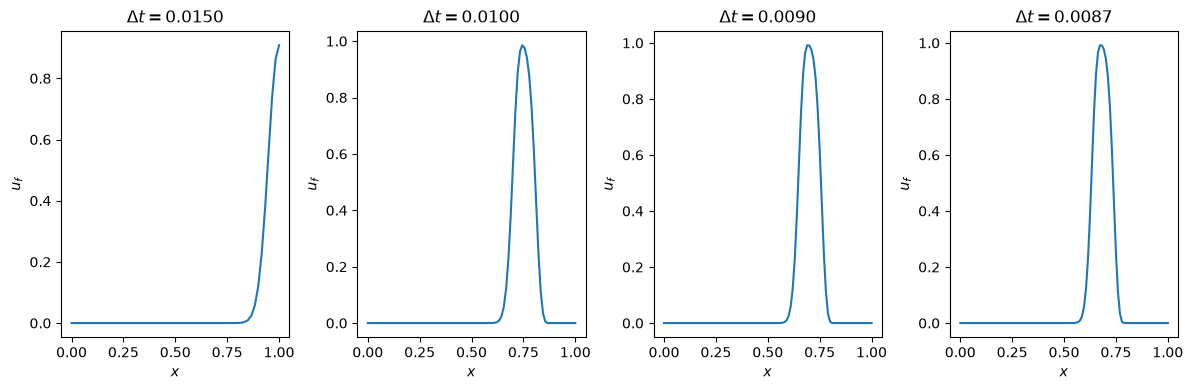

In [311]:
n_grids, x_range = [61, 91, 101, 105], [0.0, 1.0]
n_timesteps = 50

fig = plt.figure(figsize=(12, 4))

for n_grid in n_grids:
    u_0 = top_hat(domain=x_range, n_grid=n_grid)
    u, delta_t = cfl_linear_convection(u_0=u_0, domain=x_range, n_x=n_grid, n_t=n_timesteps)
    x = np.linspace(x_range[0], x_range[1], n_grid)

    ax = fig.add_subplot(1, len(n_grids), n_grids.index(n_grid)+1)
    ax.plot(x, u[-1], label=f"$n_x={n_grid}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$u_f$")
    ax.set_title(r"$\Delta t = " + f"{delta_t:.4f}$")

plt.tight_layout()
plt.show()

An important observation here is that, even though the wave speed has not been changed, as the grid resolution is increased, the wave propagates a shorter distance. Clearly, as the grid resolution is increased, the timestep decreases, so for a fixed number of iterations,  it will travel under less time. The function still struggles with negative $c$ values, so the CFL number is also implemented into the upwind scheme.

In [ ]:
def cfl_upwind_linear_convection(u_0: np.ndarray, domain: list[float], n_x: int, n_t: int, c: float = 1.0, cfl: float = 0.9) -> tuple[np.ndarray, float]:
    d_x = abs(domain[1] - domain[0]) / (n_x - 1)
    d_t = cfl * d_x / abs(c)

    u = np.zeros([n_t+1, n_x])
    u[0] = u_0

    for n in range(n_t):
        for i in range(1, n_x-1):
            
            fe1, fe2 = upwind_scheme(c)
            fw1, fw2 = upwind_scheme(c)

            ue = u[n, i] * fe1 + u[n, i+1] * fe2
            uw = u[n, i-1] * fw1 + u[n, i] * fw2

            u[n+1, i] = u[n, i] - c * d_t/d_x * (ue - uw)

    return u, d_t

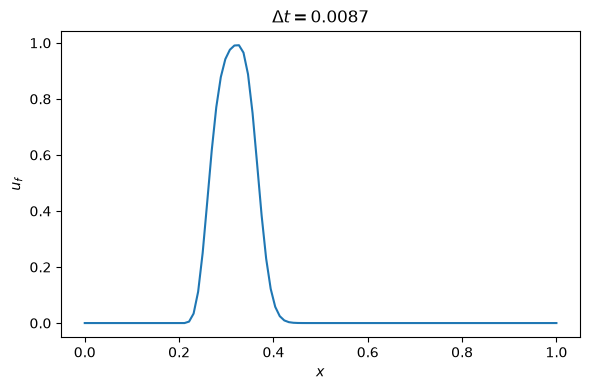

In [313]:
n_grids, x_range = 91, [0.0, 1.0]
n_timesteps = 50

fig = plt.figure(figsize=(6, 4))

u_0 = top_hat(domain=x_range, n_grid=n_grid, centre=0.75)
u, delta_t = cfl_upwind_linear_convection(u_0=u_0, domain=x_range, n_x=n_grid, n_t=n_timesteps, c=-1.0)
x = np.linspace(x_range[0], x_range[1], n_grid)

ax = fig.add_subplot(1, 1, 1)
ax.plot(x, u[-1], label=f"$n_x={n_grid}$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u_f$")
ax.set_title(r"$\Delta t = " + f"{delta_t:.4f}$")

plt.tight_layout()
plt.show()

## Diffusion eq<sup>n</sup> in 1<sup>D</sup>

The 1<sup>D</sup> diffusion eq<sup>n</sup> is

$$ \frac{\partial u}{\partial t} = \nu \frac{\partial ^2 u}{\partial x^2}$$

Discretising 2nd-order PDEs requries the Central Difference scheme: a combination of the Forward & Backward Difference of the first derivative. Consider first the Taylor expansion of $u_{i+1}$ and $u_{i-1}$ around $u_i$,

$$u_{i+1} = u_i + \Delta x \frac{\partial u}{\partial x}\Bigr|_i + \frac{\Delta x^2}{2!} \frac{\partial ^2 u}{\partial x^2}\Bigr|_i + \frac{\Delta x^3}{3!} \frac{\partial ^3 u}{\partial x^3}\Bigr|_i + \mathcal{O}(\Delta x^4)$$

$$u_{i-1} = u_i - \Delta x \frac{\partial u}{\partial x}\Bigr|_i + \frac{\Delta x^2}{2!} \frac{\partial ^2 u}{\partial x^2}\Bigr|_i - \frac{\Delta x^3}{3!} \frac{\partial ^3 u}{\partial x^3}\Bigr|_i + \mathcal{O}(\Delta x^4)$$

i.e.

$$u_{i+1} + u_{i-1} = 2u_i + \Delta x^2 \frac{\partial ^2 u}{\partial x^2}\Bigr|_i + \mathcal{O}(\Delta x^4)$$

and rearranging for the second derivative,

$$\frac{\partial ^2 u}{\partial x^2} = \frac{u_{i+1} + u_{i-1} - 2u_i}{\Delta x^2} + \mathcal{O}(\Delta x^4)$$

The diffusion eq<sup>n</sup> can therefore be numerically , letting $n$ be steps in time and $i$ steps in space.

$$\frac{u^{n+1}_i - u^n_i}{\Delta t} = \nu \frac{u^n_{i+1} - 2u^n_i + u^n_{i-1}}{\Delta x^2}$$

Rearranging for numerical solutions in time we get a discrete diffusion eq<sup>n</sup>

$$u^{n+1}_i = u^n_i + \frac{\nu \Delta t}{\Delta x^2} (u^n_{i+1} - 2u^n_i + u^n_{i-1})$$

In [ ]:
def diffusion(u_0: np.ndarray, domain: list[float], n_x: int, n_t: int, sigma: float = 0.2, nu: float = 0.3) -> np.ndarray:
    d_x = abs(domain[1] - domain[0]) / (n_x - 1)
    d_t = sigma * d_x**2 / nu

    u = np.zeros([n_t+1, n_x])
    u[0] = u_0

    for n in range(n_t):
        for i in range(1, n_x-1): # ignore last iteration as differential value depends on (i+1)th value
            u[n+1, i] = u[n, i] + nu * d_t / (d_x**2) * (u[n, i+1] - 2 * u[n, i] + u[n, i-1])

    return u

Sigma, $\sigma$ is a dimensionless stability parameter that controls the magnitude of $\Delta t$ relative to the spatial grid and the diffusion coefficient $\nu$. A smaller $\sigma$ leads to a smaller $\Delta t$, which can improve stability but increase computation time.

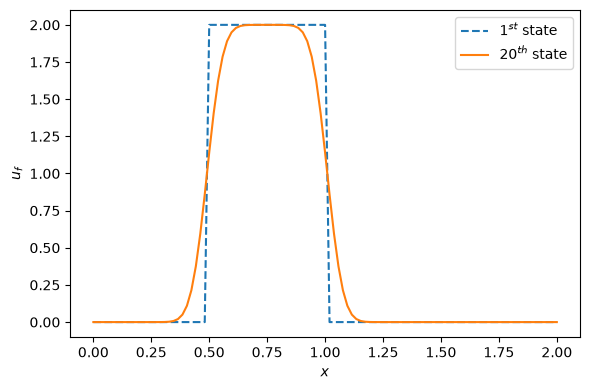

In [339]:
n_grids, x_range = 41, [0.0, 2.0]
n_timesteps = 20

fig = plt.figure(figsize=(6, 4))

u_0 = top_hat(domain=x_range, n_grid=n_grid, centre=0.75, width=0.5, max=2.0)
u = diffusion(u_0=u_0, domain=x_range, n_x=n_grid, n_t=n_timesteps)
x = np.linspace(x_range[0], x_range[1], n_grid)

ax = fig.add_subplot(1, 1, 1)
ax.plot(x, u[0], "--", label=r"1$^{st}$ state")
ax.plot(x, u[-1], label=f"{n_timesteps}" + r"$^{th}$ state")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u_f$")

plt.legend()
plt.tight_layout()
plt.show()